# Gaia Data Lightcurve Analysis

In [1]:
%pylab notebook
#%matplotlib ipympl

Populating the interactive namespace from numpy and matplotlib


In [2]:
from astropy.table import Table
from astropy.io import ascii
import lightkurve as lk 
import warnings
import pandas as pd
from astropy.units import UnitsWarning

###### uncomment the below if not using magic: ######
# import matplotlib.pyplot as plt
# import numpy as np

#### Retrieving the Gaia data of a star:

Input 
- Name of star
- Name of **output** file (the `.dat`) with *no extension*
- Name of **input** file (the `.fits`) with *no extension*

In [5]:
#######EDITABLE#######
#Insert the name of the star of interest below between the quotes.
star_name = 'TIC349059354' #what the catalogue contains
file_name = 'gaia' #must contain NO spaces or file extension
input_file_name = '5282555035278846976' #give Gaia FITS file (without extension)

In [8]:
#downloading star
with warnings.catch_warnings():

  warnings.simplefilter("ignore", UnitsWarning)

  table = Table.read(f'{input_file_name}.fits')
#Green
Gtable = table[table['band'] == 'G']

Gtable = Gtable[~Gtable['time'].mask]

Gtable = Gtable[~Gtable['flux'].mask]

Gtable = Gtable[~Gtable['flux_error'].mask]

Gtable = Gtable[~Gtable['mag'].mask]

lcG = lk.LightCurve(time=Gtable['time'].filled().value + 2455197.5-2457000,
                    flux=Gtable['flux'].filled().value,
                    flux_err=Gtable['flux_error'].filled().value)

lcG['mag'] = Gtable['mag'].filled().value

#Red
Gtable = table[table['band'] == 'RP']

Gtable = Gtable[~Gtable['time'].mask]

Gtable = Gtable[~Gtable['flux'].mask]

Gtable = Gtable[~Gtable['flux_error'].mask]

Gtable = Gtable[~Gtable['mag'].mask]

lcR = lk.LightCurve(time=Gtable['time'].filled().value + 2455197.5-2457000, 
                    flux=Gtable['flux'].filled().value,
                    flux_err=Gtable['flux_error'].filled().value)

lcR['mag'] = Gtable['mag'].filled().value

#Blue
Gtable = table[table['band'] == 'BP']

Gtable = Gtable[~Gtable['time'].mask]

Gtable = Gtable[~Gtable['flux'].mask]

Gtable = Gtable[~Gtable['flux_error'].mask]

Gtable = Gtable[~Gtable['mag'].mask]

lcB = lk.LightCurve(time=Gtable['time'].filled().value + 2455197.5 - 2457000, 
                    flux=Gtable['flux'].filled().value,
                    flux_err=Gtable['flux_error'].filled().value)

lcB['mag'] = Gtable['mag'].filled().value

table

source_id,transit_id,band,time,mag,flux,flux_error,flux_over_error,rejected_by_photometry,rejected_by_variability,other_flags,solution_id
,,,d,mag,'electron'.s**-1,'electron'.s**-1,,,,,
int64,int64,bytes2,float64,float64,float64,float64,float32,bool,bool,int64,int64
5282555035278846976,15071794866319854,G,1669.4090368194018,11.395629571084251,520828.71270365437,586.9926816922742,887.28314,False,False,4097,375316653866487564
5282555035278846976,15085628028253284,G,1669.6591883332544,11.399527317730076,518962.31200315745,1176.7630396042534,441.00833,False,False,4097,375316653866487564
5282555035278846976,15099461191366364,G,1669.9093651361015,11.396376090045601,520470.7299154201,491.5344578921494,1058.8693,False,False,4097,375316653866487564
5282555035278846976,15113294348312947,G,1670.1595148579786,11.556947573237181,448918.72163500095,740.6211130883119,606.1382,False,False,5119,375316653866487564
5282555035278846976,15127127500153836,G,1670.4096850233116,11.404248831027823,516710.4137891165,680.1640544323521,759.685,False,False,4097,375316653866487564
5282555035278846976,15131219809464878,G,1670.4836926782843,11.405040575528233,516333.7536950466,552.7778374229073,934.071,False,False,4097,375316653866487564
5282555035278846976,15140960645703269,G,1670.6598440348655,11.407343863730786,515239.5607668832,679.2712262725383,758.5182,False,False,4097,375316653866487564
5282555035278846976,15145052953834662,G,1670.7338609824403,11.397209929926913,520071.1644946083,553.0434310198181,940.3803,False,False,4097,375316653866487564


#### Removing the messy bits: Red

<IPython.core.display.Javascript object>


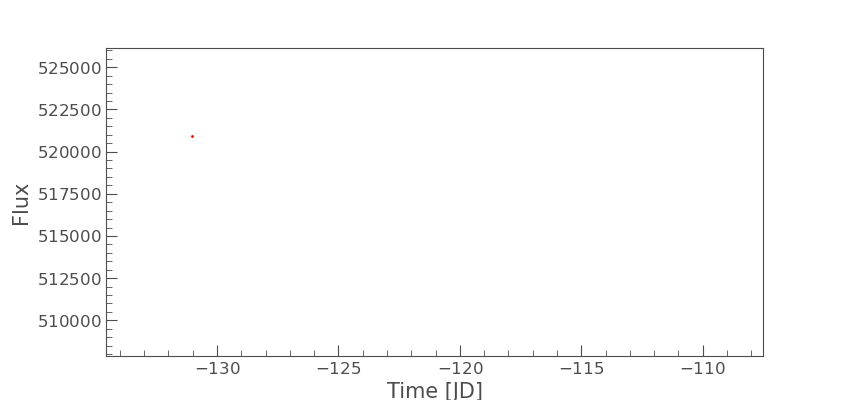

<AxesSubplot:xlabel='Time [JD]', ylabel='Flux'>

In [16]:
#%matplotlib ipympl
#Look at scatter diagram to remove bad data points

lcR.scatter(c='r')
#plt.show()

In [17]:
#######EDITABLE#######
#Examine the light curve(s) of interest above using the interactive plot tool.
#Insert the start and end time(s) of the unwanted patch(es) of data into the following variables respectively.
bad_dat_start_list = [] #The start times of individual unwanted patches are separated by ','.
bad_dat_end_list =  []  #The end times of individual unwanted patches are separated by ','.

bad_flux_bottom = [500000] #bottom (y values) of bad values
bad_flux_top = [522500] # top (y values) of bad values

In [18]:
good_lc = lcR.copy()
for bad_dat_start,bad_dat_end in zip(bad_dat_start_list,bad_dat_end_list):
    print('Removing data from ',bad_dat_start,' to ',bad_dat_end)
    #Extracting and displaying the good data
    good_data_mask =  (good_lc.time.value < bad_dat_start) | (good_lc.time.value > bad_dat_end)
    good_lc = good_lc[good_data_mask]

for bad_dat_start,bad_dat_end in zip(bad_flux_bottom,bad_flux_top):
    print('Removing data from ',bad_dat_start,' to ',bad_dat_end)
    #Extracting and displaying the good data
    good_data_mask =  (good_lc.flux.value < bad_dat_start) | (good_lc.flux.value > bad_dat_end)
    good_lc = good_lc[good_data_mask]

Removing data from  500000  to  522500


<IPython.core.display.Javascript object>


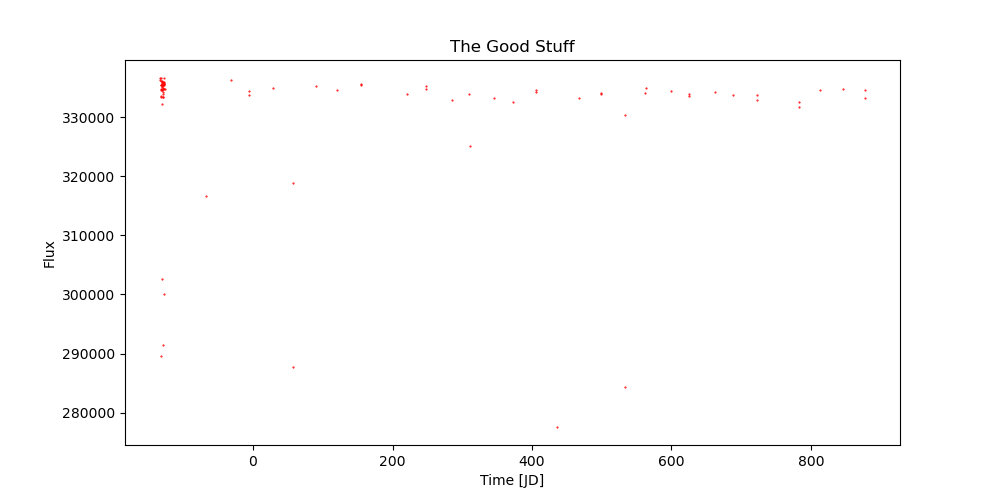

Text(0.5, 1.0, 'The Good Stuff')

In [19]:
#Plotting the good data
fig, ax = plt.subplots(figsize=(10,5))
good_lc.scatter(ax=ax, s=1, color='red')
ax.set_title('The Good Stuff')
#plt.show()

In [20]:
#Saving good_lc to a separate lightcurve
lcR_final = good_lc

#### Removing the messy bits: Blue

<IPython.core.display.Javascript object>


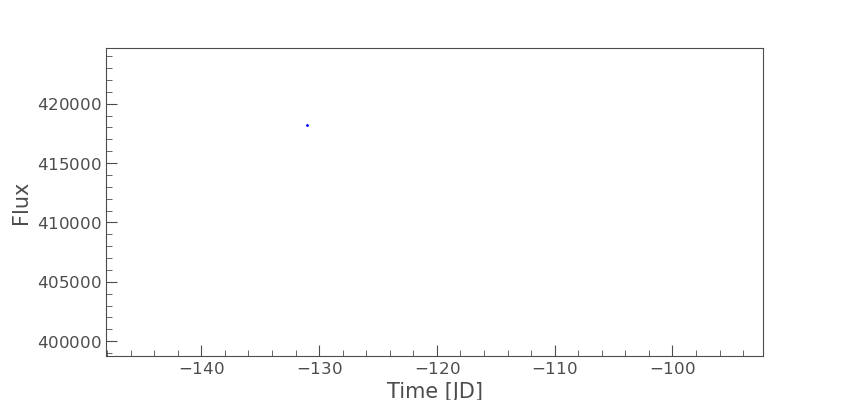

In [21]:
#Look at scatter diagram to remove bad data points
lcB.scatter(c='b');
#plt.show()

In [22]:
#######EDITABLE#######
#Examine the light curve(s) of interest above using the interactive plot tool.
#Insert the start and end time(s) of the unwanted patch(es) of data into the following variables respectively.
bad_dat_start_list = [] #The start times of individual unwanted patches are separated by ','.
bad_dat_end_list =  []  #The end times of individual unwanted patches are separated by ','.

bad_flux_bottom = [415000] #bottom (y values) of bad values
bad_flux_top = [420000] # top (y values) of bad values

In [23]:
good_lc = lcB.copy()
for bad_dat_start,bad_dat_end in zip(bad_dat_start_list,bad_dat_end_list):
    print('Removing data from ',bad_dat_start,' to ',bad_dat_end)
    #Extracting and displaying the good data
    good_data_mask =  (good_lc.time.value < bad_dat_start) | (good_lc.time.value > bad_dat_end)
    good_lc = good_lc[good_data_mask]

for bad_dat_start,bad_dat_end in zip(bad_flux_bottom,bad_flux_top):
    print('Removing data from ',bad_dat_start,' to ',bad_dat_end)
    #Extracting and displaying the good data
    good_data_mask =  (good_lc.flux.value < bad_dat_start) | (good_lc.flux.value > bad_dat_end)
    good_lc = good_lc[good_data_mask]

Removing data from  415000  to  420000


<IPython.core.display.Javascript object>


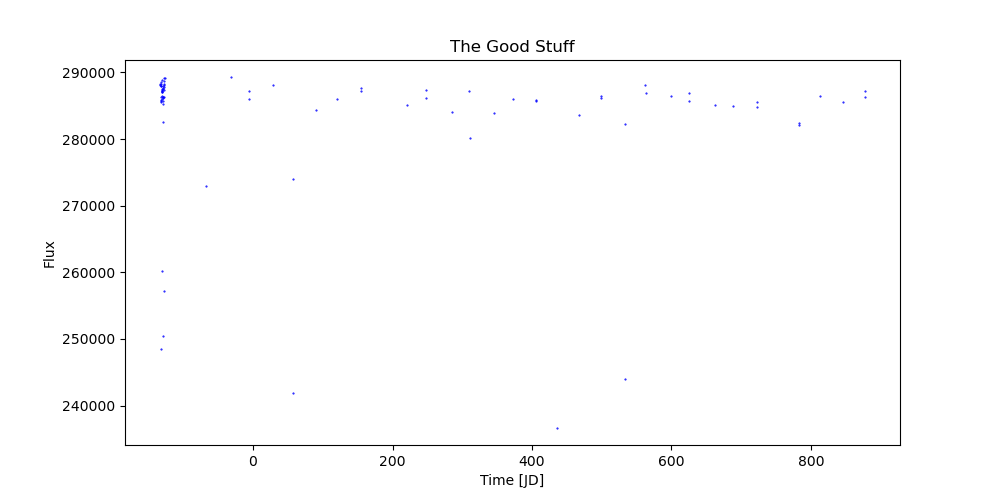

Text(0.5, 1.0, 'The Good Stuff')

In [24]:
#Plotting the good data
fig, ax = plt.subplots(figsize=(10,5))
good_lc.scatter(ax=ax, s=1, color='b')
ax.set_title('The Good Stuff')
#plt.show()

In [25]:
#Saving good_lc to a separate lightcurve
lcB_final = good_lc

#### Removing the messy bits: Green

<IPython.core.display.Javascript object>


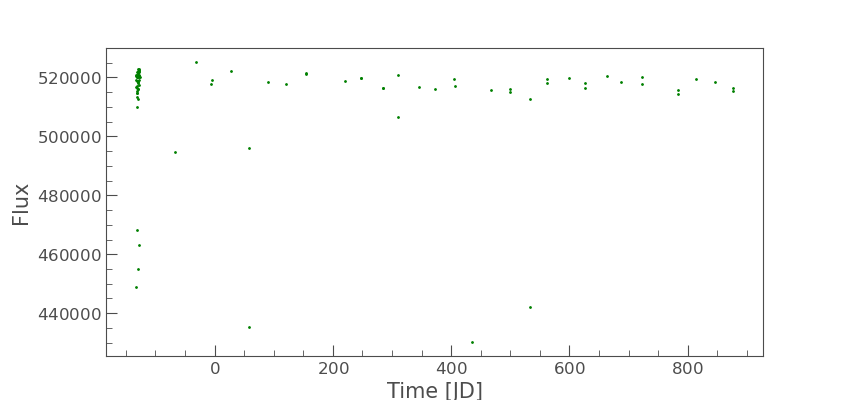

In [26]:
#Look at scatter diagram to remove bad data points
lcG.scatter(c='g');
#plt.show()

In [27]:
#######EDITABLE#######
#Examine the light curve(s) of interest above using the interactive plot tool.
#Insert the start and end time(s) of the unwanted patch(es) of data into the following variables respectively.
bad_dat_start_list = [] #The start times of individual unwanted patches are separated by ','.
bad_dat_end_list =  []  #The end times of individual unwanted patches are separated by ','.

bad_flux_bottom = [] #bottom (y values) of bad values
bad_flux_top = [] # top (y values) of bad values

In [28]:
good_lc = lcG.copy()
for bad_dat_start,bad_dat_end in zip(bad_dat_start_list,bad_dat_end_list):
    print('Removing data from ',bad_dat_start,' to ',bad_dat_end)
    #Extracting and displaying the good data
    good_data_mask =  (good_lc.time.value < bad_dat_start) | (good_lc.time.value > bad_dat_end)
    good_lc = good_lc[good_data_mask]

for bad_dat_start,bad_dat_end in zip(bad_flux_bottom,bad_flux_top):
    print('Removing data from ',bad_dat_start,' to ',bad_dat_end)
    #Extracting and displaying the good data
    good_data_mask =  (good_lc.flux.value < bad_dat_start) | (good_lc.flux.value > bad_dat_end)
    good_lc = good_lc[good_data_mask]

<IPython.core.display.Javascript object>


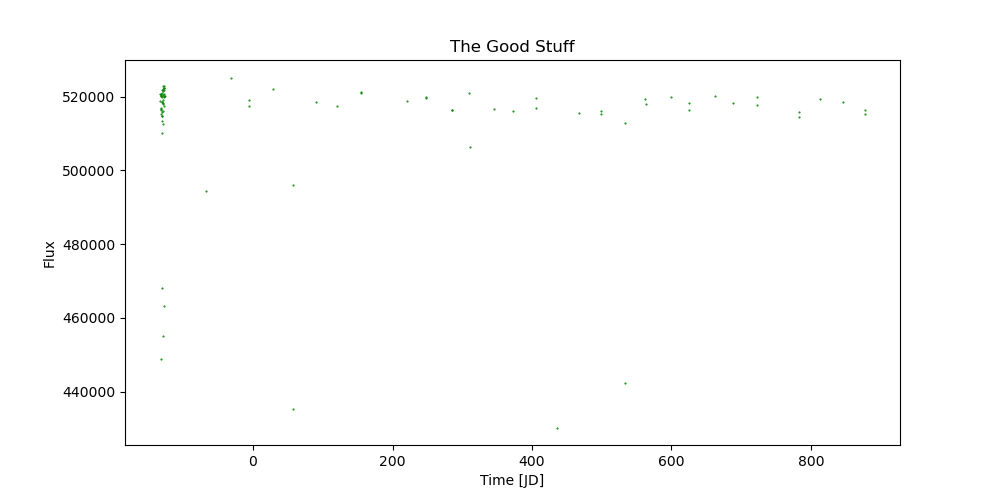

Text(0.5, 1.0, 'The Good Stuff')

In [29]:
#Plotting the good data
fig, ax = plt.subplots(figsize=(10,5))
good_lc.scatter(ax=ax, s=1, color='g')
ax.set_title('The Good Stuff')

In [30]:
#Saving good_lc to a separate lightcurve
lcG_final = good_lc

#### Save all for use in jktebop

In [31]:
#####Save Red#####
good_lc = lcR_final

#read in flux
flux = good_lc.flux.value
#read in flux error 
flux_err = good_lc.flux_err.value
#Calculate magnitude error from flux
Mag_err = (abs((-2.5*np.log10(flux+flux_err))-(-2.5*np.log10(flux)))+abs((-2.5*np.log10(flux))-(-2.5*np.log10(flux-flux_err))))/2
#Calculate magnitude
Mag = good_lc.mag.value
#read in time values
time = good_lc.time.value

#create a new table
jktebop_table = Table()
#add values to table
jktebop_table['Time'] = time
jktebop_table['Mag'] = Mag
jktebop_table['Mag_err'] = Mag_err

#write table to txt file
ascii.write(jktebop_table, f'{file_name}.red.gaia.dat', overwrite=True) 

#read in table, removing NaN values
test_file = pd.read_csv(f'{file_name}.red.gaia.dat',delimiter = ' ').dropna()

#upload table to txt in correct format
#header removed to not confuse jktebop
test_file.to_csv(f'{file_name}.red.gaia.dat',index=False,header=False,sep='\t')

#printing values needed for use in jktebop parameters
print('Red Table written!')

#####Save Blue#####
good_lc = lcB_final

#read in flux
flux = good_lc.flux.value
#read in flux error 
flux_err = good_lc.flux_err.value
#Calculate magnitude error from flux
Mag_err = (abs((-2.5*np.log10(flux+flux_err))-(-2.5*np.log10(flux)))+abs((-2.5*np.log10(flux))-(-2.5*np.log10(flux-flux_err))))/2
#Calculate magnitude
Mag = good_lc.mag.value
#read in time values
time = good_lc.time.value

#create a new table
jktebop_table = Table()
#add values to table
jktebop_table['Time'] = time
jktebop_table['Mag'] = Mag
jktebop_table['Mag_err'] = Mag_err

#write table to txt file
ascii.write(jktebop_table, f'{file_name}.blue.gaia.dat', overwrite=True) 

#read in table, removing NaN values
test_file = pd.read_csv(f'{file_name}.blue.gaia.dat',delimiter = ' ').dropna()

#upload table to txt in correct format
#header removed to not confuse jktebop
test_file.to_csv(f'{file_name}.blue.gaia.dat',index=False,header=False,sep='\t')

#printing values needed for use in jktebop parameters
print('Blue Table written!')

#####Save Green#####
good_lc = lcG_final

#read in flux
flux = good_lc.flux.value
#read in flux error 
flux_err = good_lc.flux_err.value
#Calculate magnitude error from flux
Mag_err = (abs((-2.5*np.log10(flux+flux_err))-(-2.5*np.log10(flux)))+abs((-2.5*np.log10(flux))-(-2.5*np.log10(flux-flux_err))))/2
#Calculate magnitude
Mag = good_lc.mag.value
#read in time values
time = good_lc.time.value

#create a new table
jktebop_table = Table()
#add values to table
jktebop_table['Time'] = time
jktebop_table['Mag'] = Mag
jktebop_table['Mag_err'] = Mag_err

#write table to txt file
ascii.write(jktebop_table, f'{file_name}.green.gaia.dat', overwrite=True) 

#read in table, removing NaN values
test_file = pd.read_csv(f'{file_name}.green.gaia.dat',delimiter = ' ').dropna()

#upload table to txt in correct format
#header removed to not confuse jktebop
test_file.to_csv(f'{file_name}.green.gaia.dat',index=False,header=False,sep='\t')

#printing values needed for use in jktebop parameters
print('Green Table written!')

Red Table written!
Blue Table written!
Green Table written!
